# Verification: Dushek et al. (2011), membrane-anchored multisite phosphorylation

`models/membrane_anchored_multisite_phosphorylation_dushek2011` reproduces the paper's
two-step model: a kinase and a phosphatase, both confined to the membrane and both in excess
of the substrate, reach an **encounter complex** with an N-site substrate before they can
bind, and are left briefly **refractory** after catalysis.

**Level 1 — model specification.** Every reaction is a first-order transition of one
substrate molecule (the generated network has *zero* bimolecular reactions), so the model is
a linear continuous-time Markov chain and its steady state is the **null space of the
generator** — exact, with no solver tolerance at all. `independent_dushek2011.py` assembles
that chain from Eq. 1 and Table 1, state by state; it shares no code with BioNetGen and never
reads the generated `.net`.

Two further level-1 checks come free:

* the hand-derived state count is 7N+3 = **143** at N = 20 — the "143 coupled ODEs" the paper
  reports, and the number BioNetGen produces independently;
* the model has an exact symmetry, ⟨S⟩(r) + ⟨S⟩(1/r) = 1, because kinase and phosphatase carry
  identical constants. Every curve must pass through 0.5 at [E]/[F] = 1.

**Level 2 — reported data.** Fig. 2 is four panels of twenty dose–response curves. All eighty
are digitized from the page's vector paths by `digitize_dushek2011.py` and compared here, and
the Hill-number insets are compared against the fits the paper prints on them.

**A discrepancy resolved by measurement.** The main text defines the reaction-limited regime as
`k_on = k₊/100`. That does not reproduce the published panel; `k_on = k₊/10` does. This
notebook makes the measurement that settles it.

In [1]:
import csv, shutil, subprocess, sys, tempfile
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

HERE = Path.cwd()
sys.path.insert(0, str(HERE))
sys.path.insert(0, str(HERE / "generator"))
sys.path.insert(0, str(HERE.parents[1] / "skills/curate-model/scripts"))

import independent_dushek2011 as ind
import build_dushek2011 as gen
from verification_figure import verdict_footer

STEM = "membrane_anchored_multisite_phosphorylation_dushek2011"
BNG = shutil.which("bionetgen") or str(HERE.parents[1] / ".venv" / "bin" / "bionetgen")
USE_CLI = Path(BNG).exists()
if not USE_CLI:
    BNG = shutil.which("BNG2.pl") or "/Users/wish/Simulations/BioNetGen-2.9.3/BNG2.pl"
print("BioNetGen:", BNG)

def run(bngl: Path, outdir: Path):
    outdir.mkdir(parents=True, exist_ok=True)
    cmd = ([BNG, "run", "-i", str(bngl), "-o", str(outdir)] if USE_CLI
           else ["perl", BNG, "--outdir", str(outdir), str(bngl)])
    r = subprocess.run(cmd, capture_output=True, text=True)
    assert r.returncode == 0, r.stdout[-3000:] + r.stderr[-3000:]

def scan(path):
    a = np.loadtxt(path, comments="#")
    hdr = open(path).readline().split()[1:]
    return a[:, 0], {h: a[:, i] for i, h in enumerate(hdr)}

# The four panels of Fig. 2, and which committed file + scan produces each.
PANELS = [
    ("2A", "reaction",  False, f"{STEM}_nonrefractory_scan_reaction.scan"),
    ("2B", "diffusion", False, f"{STEM}_nonrefractory_scan.scan"),
    ("2C", "reaction",  True,  f"{STEM}_scan_reaction.scan"),
    ("2D", "diffusion", True,  f"{STEM}_scan.scan"),
]
TMP = Path(tempfile.mkdtemp(prefix="dushek_"))
for f in (f"{STEM}.bngl", f"{STEM}_nonrefractory.bngl"):
    run(HERE / f, TMP)
    print("ran", f)

BioNetGen: /Users/wish/Code/BNGL-Models/.venv/bin/bionetgen


ran membrane_anchored_multisite_phosphorylation_dushek2011.bngl


ran membrane_anchored_multisite_phosphorylation_dushek2011_nonrefractory.bngl


## Level 1 — BioNetGen against the exact null space

In [2]:
N = 20
rows, l1 = [], 0.0
for key, regime, refr, fn in PANELS:
    r, g = scan(TMP / fn)
    bng = g["Obs_pY"] / N
    exact = np.array([ind.mean_phosphorylation(N, regime, x, refractory=refr) for x in r])
    d = float(np.abs(bng - exact).max())
    l1 = max(l1, d)
    rows.append((key, regime, refr, r, bng, exact, d))
    print(f"  Fig {key}  {regime:9}-limited, {'refractory' if refr else 'non-refractory':14}"
          f"  max |BNG - exact| over {len(r)} scan points: {d:.2e}")

L1_TOL = 1e-6
print(f"\nlevel 1: max absolute difference {l1:.2e} (tolerance {L1_TOL:.0e}) -> "
      f"{'PASS' if l1 < L1_TOL else 'FAIL'}")
print("tolerance rationale: the exact side has NO numerical error -- it is a null space, not "
      "an integration -- so the residual is BioNetGen's steady-state tolerance alone.")

# Structural checks that need no tolerance at all.
net = (TMP / f"{STEM}.net").read_text()
nsp = len(net.split("begin species")[1].split("end species")[0].strip().split("\n"))
nrx = len(net.split("begin reactions")[1].split("end reactions")[0].strip().split("\n"))
nbi = sum(1 for l in net.split("begin reactions")[1].split("end reactions")[0].strip().split("\n")
          if "," in l.split()[1])
print(f"\nnetwork: {nsp} species, {nrx} reactions, {nbi} bimolecular reactions")
print(f"  hand-derived state count 7N+3 = {7*N+3}; the paper reports '143 coupled ODEs'")
assert (nsp, nrx, nbi) == (7*N+3, 14*N+4, 0)

# BioNetGen supplies the site multiplicity; the authors hard-coded it into 40 constants.
laws = sorted({l.split()[3] for l in
               net.split("begin reactions")[1].split("end reactions")[0].strip().split("\n")
               if "R_bind_E" in l and "_reverse" not in l},
              key=lambda s: (len(s), s))
print(f"  kinase-binding rate laws generated: {laws[0]}, {laws[1]}, ... , {laws[-1]}")

sym = max(abs(ind.mean_phosphorylation(n, "diffusion", x)
              + ind.mean_phosphorylation(n, "diffusion", 1/x) - 1.0)
          for n in (1, 5, 20) for x in (0.01, 0.1, 3.0))
print(f"  exact symmetry <S>(r) + <S>(1/r) = 1 holds to {sym:.1e}")

  Fig 2A  reaction -limited, non-refractory  max |BNG - exact| over 41 scan points: 2.55e-09
  Fig 2B  diffusion-limited, non-refractory  max |BNG - exact| over 41 scan points: 5.15e-09
  Fig 2C  reaction -limited, refractory      max |BNG - exact| over 41 scan points: 3.37e-09
  Fig 2D  diffusion-limited, refractory      max |BNG - exact| over 41 scan points: 1.14e-08

level 1: max absolute difference 1.14e-08 (tolerance 1e-06) -> PASS
tolerance rationale: the exact side has NO numerical error -- it is a null space, not an integration -- so the residual is BioNetGen's steady-state tolerance alone.

network: 143 species, 284 reactions, 0 bimolecular reactions
  hand-derived state count 7N+3 = 143; the paper reports '143 coupled ODEs'
  kinase-binding rate laws generated: k_on_star, 2*k_on_star, ... , 20*k_on_star
  exact symmetry <S>(r) + <S>(1/r) = 1 holds to 2.7e-09


## The reaction-limited `k_on`: the main text says k₊/100, the panel says k₊/10

The Fig. 2 caption gives `k₊`, `koff`, `kr` and `A`, but not `k_on`; the main text supplies it
as *"the reaction-limited regime (k_on = k₊/100)"*. At `k₊ = 10 µm²/s` that is `k_on = 0.1`.

The Hill-number insets cannot tell the two apart — both give ≈ 1 for every N. The curve
*shape* can: the N = 1 curve of panel 2A is the paper's subsensitivity result, and its span is
a strong function of `k_on`. Below, the digitized panel is compared against both candidates.

In [3]:
figa = defaultdict(list)
with open(HERE / "reference" / "dushek2011_figa_digitized.csv") as fh:
    for row in csv.DictReader(l for l in fh if not l.startswith("#")):
        figa[int(row["n_sites"])].append((float(row["log10_E_over_F"]),
                                          float(row["total_phosphorylation"])))
d1 = np.array(sorted(figa[1]))
meas_lo, meas_hi = d1[0, 1], d1[-1, 1]
print(f"digitized Fig. 2A, N = 1: spans {meas_lo:.4f} at log10([E]/[F]) = {d1[0,0]:.2f} "
      f"to {meas_hi:.4f} at {d1[-1,0]:.2f}")

KON = {}
for kon in (0.1, 1.0):
    ind.REGIMES["reaction"] = (10.0, kon)
    lo = ind.mean_phosphorylation(1, "reaction", 10**d1[0, 0], refractory=False)
    hi = ind.mean_phosphorylation(1, "reaction", 10**d1[-1, 0], refractory=False)
    err = max(abs(lo - meas_lo), abs(hi - meas_hi))
    KON[kon] = err
    print(f"  k_on = {kon:4} (= k+/{int(10/kon):3d}): model spans {lo:.4f} .. {hi:.4f}"
          f"   worst |model - figure| = {err:.4f} of full scale")
ind.REGIMES["reaction"] = (10.0, 1.0)          # restore the curated value
print(f"\nk_on = k+/10 is better by a factor of {KON[0.1]/KON[1.0]:.0f}. The curated files use "
      f"k_on = 1 um^2/s and record the discrepancy in their headers.")

digitized Fig. 2A, N = 1: spans 0.4715 at log10([E]/[F]) = -2.00 to 0.5292 at 1.99
  k_on =  0.1 (= k+/100): model spans 0.3129 .. 0.6843   worst |model - figure| = 0.1586 of full scale
  k_on =  1.0 (= k+/ 10): model spans 0.4713 .. 0.5281   worst |model - figure| = 0.0011 of full scale

k_on = k+/10 is better by a factor of 145. The curated files use k_on = 1 um^2/s and record the discrepancy in their headers.


## Level 2 — all 80 published curves of Fig. 2

In [4]:
L2_TOL = 0.02
digi, l2 = {}, []
for key, regime, refr, _ in PANELS:
    p = HERE / "reference" / f"dushek2011_fig{key[1].lower()}_digitized.csv"
    d = defaultdict(list)
    with open(p) as fh:
        for row in csv.DictReader(l for l in fh if not l.startswith("#")):
            d[int(row["n_sites"])].append((float(row["log10_E_over_F"]),
                                           float(row["total_phosphorylation"])))
    digi[key] = {n: np.array(sorted(v)) for n, v in d.items()}
    errs = []
    for n, v in digi[key].items():
        m = np.array([ind.mean_phosphorylation(n, regime, 10.0**t, refractory=refr)
                      for t in v[:, 0]])
        errs.append((float(np.sqrt(np.mean((m - v[:, 1])**2))), n))
    errs.sort(reverse=True)
    l2 += [e for e, _ in errs]
    print(f"  Fig {key}: {len(errs)} curves, RMSE median {np.median([e for e,_ in errs]):.4f}, "
          f"max {errs[0][0]:.4f} (N = {errs[0][1]})")

L2_MAX, L2_MED = max(l2), float(np.median(l2))
print(f"\nlevel 2: {len(l2)} curves; RMSE max {L2_MAX:.4f}, median {L2_MED:.4f} of full scale "
      f"(tolerance {L2_TOL:.2f}) -> {'PASS' if L2_MAX < L2_TOL else 'FAIL'}")
print("tolerance rationale: the route is vector, so there is no digitization error in the "
      "geometry -- the residual error is the axes calibration, measured at <= 0.0019 of panel "
      "size against the exact (0, 0.5) crossing, plus the 0.85 pt stroke width (~0.008 of "
      "panel height). 0.02 is about twice that budget.")

  Fig 2A: 20 curves, RMSE median 0.0023, max 0.0027 (N = 17)


  Fig 2B: 20 curves, RMSE median 0.0008, max 0.0014 (N = 20)


  Fig 2C: 20 curves, RMSE median 0.0020, max 0.0021 (N = 18)


  Fig 2D: 20 curves, RMSE median 0.0033, max 0.0040 (N = 19)

level 2: 80 curves; RMSE max 0.0040, median 0.0021 of full scale (tolerance 0.02) -> PASS
tolerance rationale: the route is vector, so there is no digitization error in the geometry -- the residual error is the axes calibration, measured at <= 0.0019 of panel size against the exact (0, 0.5) crossing, plus the 0.85 pt stroke width (~0.008 of panel height). 0.02 is about twice that budget.


## The Hill-number insets

Each panel carries an inset plotting the Hill number against the number of sites, with a
fitted line printed on it. Those printed fits are reported data in their own right and need no
digitizing.

`N = 1` is excluded: the N = 1 dose–response is not a Hill function at all (a Hill fit leaves
a residual of 0.021 on a curve whose total span is 0.057), so its "Hill number" is an artifact
of whichever definition is used rather than a property of the model.

In [5]:
PUBLISHED = {"2A": (0.99, 0.00), "2C": (0.98, 0.00), "2D": (0.58, 0.24)}
Ns = np.arange(2, 21)
hill = {}
for key, regime, refr, _ in PANELS:
    hill[key] = np.array([ind.hill_number(n, regime, refractory=refr) for n in Ns])
    if key in PUBLISHED:
        a, b = PUBLISHED[key]
        pred = a + b * Ns
        print(f"  Fig {key}: published Hill = {a:.2f} + {b:.2f} N   "
              f"model at N=20 {hill[key][-1]:.2f} vs {pred[-1]:.2f}   "
              f"max |model - published| over N=2..20: {np.abs(hill[key]-pred).max():.2f}")
    else:
        print(f"  Fig {key}: inset fit not legible in the source; model spans "
              f"{hill[key][0]:.2f} .. {hill[key][-1]:.2f} (the curves collapse, as the text says)")
HILL_ERR = max(float(np.abs(hill[k] - (PUBLISHED[k][0] + PUBLISHED[k][1]*Ns)).max())
               for k in PUBLISHED)
print(f"\nworst Hill-number disagreement across the three legible insets: {HILL_ERR:.2f}")

  Fig 2A: published Hill = 0.99 + 0.00 N   model at N=20 1.00 vs 0.99   max |model - published| over N=2..20: 0.02


  Fig 2B: inset fit not legible in the source; model spans 0.01 .. 0.94 (the curves collapse, as the text says)


  Fig 2C: published Hill = 0.98 + 0.00 N   model at N=20 1.08 vs 0.98   max |model - published| over N=2..20: 0.10


  Fig 2D: published Hill = 0.58 + 0.24 N   model at N=20 5.39 vs 5.38   max |model - published| over N=2..20: 0.12

worst Hill-number disagreement across the three legible insets: 0.12


## The verification figure

wrote verify_dushek2011.png


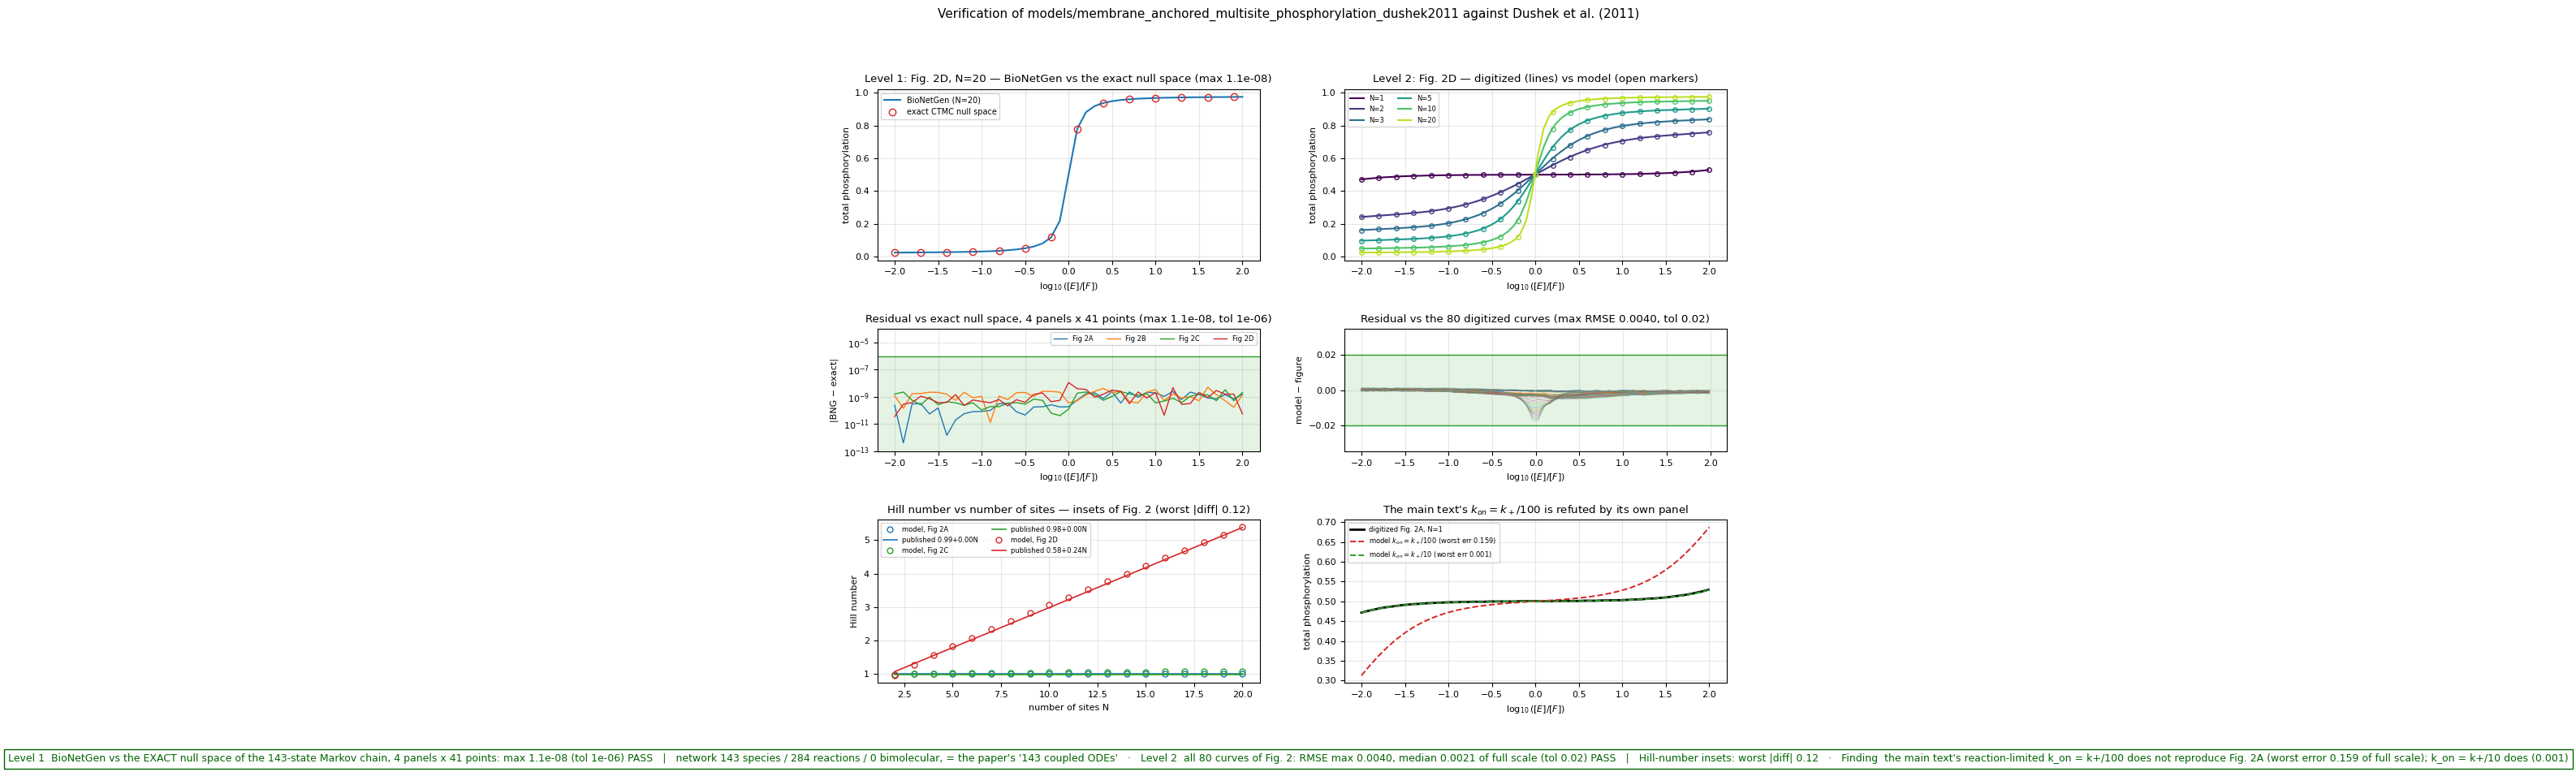

In [6]:
plt.rcParams.update({"font.size": 8, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.axisbelow": True})
fig = plt.figure(figsize=(13.5, 9.5))
gs = fig.add_gridspec(3, 2, height_ratios=[1.05, 0.75, 1.0], hspace=0.45, wspace=0.22)
SHOW = [1, 2, 3, 5, 10, 20]
cmap = plt.cm.viridis(np.linspace(0, 0.9, len(SHOW)))

# (0,0) level 1 overlay, panel 2D (the headline)
ax = fig.add_subplot(gs[0, 0])
key, regime, refr, _ = PANELS[3]
r, g = scan(TMP / PANELS[3][3])
ax.plot(np.log10(r), g["Obs_pY"] / N, lw=1.5, color="tab:blue", label="BioNetGen (N=20)")
xe = np.linspace(-2, 2, 41)
ye = [ind.mean_phosphorylation(N, regime, 10.0**t, refractory=refr) for t in xe]
ax.plot(xe[::3], np.array(ye)[::3], "o", mfc="none", mec="tab:red", ms=6,
        label="exact CTMC null space")
ax.set_title(f"Level 1: Fig. 2D, N=20 — BioNetGen vs the exact null space (max {l1:.1e})")
ax.set_xlabel(r"$\log_{10}([E]/[F])$"); ax.set_ylabel("total phosphorylation")
ax.legend(fontsize=7, loc="upper left")

# (0,1) level 2 overlay, panel 2D, several N
ax = fig.add_subplot(gs[0, 1])
for c, n in zip(cmap, SHOW):
    v = digi["2D"][n]
    ax.plot(v[:, 0], v[:, 1], lw=1.5, color=c, label=f"N={n}")
    xs = np.linspace(-2, 2, 21)
    ys = [ind.mean_phosphorylation(n, "diffusion", 10.0**t) for t in xs]
    ax.plot(xs, ys, "o", mfc="none", mec=c, ms=4)
ax.set_title("Level 2: Fig. 2D — digitized (lines) vs model (open markers)")
ax.set_xlabel(r"$\log_{10}([E]/[F])$"); ax.set_ylabel("total phosphorylation")
ax.legend(fontsize=6, ncol=2, loc="upper left")

# (1,0) level 1 residual, all four panels
ax = fig.add_subplot(gs[1, 0])
for key, regime, refr, rr, bng, exact, d in rows:
    ax.semilogy(np.log10(rr), np.maximum(np.abs(bng - exact), 1e-16), lw=1.0, label=f"Fig {key}")
ax.axhspan(1e-16, L1_TOL, color="tab:green", alpha=0.12)
ax.axhline(L1_TOL, color="tab:green", lw=1.0)
ax.set_ylim(1e-13, 1e-4)
ax.set_title(f"Residual vs exact null space, 4 panels x 41 points (max {l1:.1e}, tol {L1_TOL:.0e})")
ax.set_xlabel(r"$\log_{10}([E]/[F])$"); ax.set_ylabel("|BNG − exact|")
ax.legend(fontsize=6, ncol=4)

# (1,1) level 2 residual, all 80 curves
ax = fig.add_subplot(gs[1, 1])
for key, regime, refr, _ in PANELS:
    for n, v in digi[key].items():
        m = np.array([ind.mean_phosphorylation(n, regime, 10.0**t, refractory=refr)
                      for t in v[:, 0]])
        ax.plot(v[:, 0], m - v[:, 1], lw=0.5, alpha=0.5)
ax.axhspan(-L2_TOL, L2_TOL, color="tab:green", alpha=0.12)
for s in (-1, 1):
    ax.axhline(s * L2_TOL, color="tab:green", lw=1.0)
ax.set_ylim(-0.035, 0.035)
ax.set_title(f"Residual vs the 80 digitized curves (max RMSE {L2_MAX:.4f}, tol {L2_TOL:.2f})")
ax.set_xlabel(r"$\log_{10}([E]/[F])$"); ax.set_ylabel("model − figure")

# (2,0) Hill numbers vs the published inset fits
ax = fig.add_subplot(gs[2, 0])
col = {"2A": "tab:blue", "2B": "tab:grey", "2C": "tab:green", "2D": "tab:red"}
for key in ("2A", "2C", "2D"):
    ax.plot(Ns, hill[key], "o", mfc="none", mec=col[key], ms=5, label=f"model, Fig {key}")
    a, b = PUBLISHED[key]
    ax.plot(Ns, a + b * Ns, "-", color=col[key], lw=1.2,
            label=f"published {a:.2f}+{b:.2f}N")
ax.set_title(f"Hill number vs number of sites — insets of Fig. 2 (worst |diff| {HILL_ERR:.2f})")
ax.set_xlabel("number of sites N"); ax.set_ylabel("Hill number")
ax.legend(fontsize=6, ncol=2)

# (2,1) the k_on determination
ax = fig.add_subplot(gs[2, 1])
ax.plot(d1[:, 0], d1[:, 1], lw=2.0, color="k", label="digitized Fig. 2A, N=1")
for kon, c in ((0.1, "tab:red"), (1.0, "tab:green")):
    ind.REGIMES["reaction"] = (10.0, kon)
    xs = np.linspace(-2, 2, 41)
    ys = [ind.mean_phosphorylation(1, "reaction", 10.0**t, refractory=False) for t in xs]
    ax.plot(xs, ys, "--", color=c, lw=1.4,
            label=f"model $k_{{on}}=k_+/{int(10/kon)}$ (worst err {KON[kon]:.3f})")
ind.REGIMES["reaction"] = (10.0, 1.0)
ax.set_title("The main text's $k_{on}=k_+/100$ is refuted by its own panel")
ax.set_xlabel(r"$\log_{10}([E]/[F])$"); ax.set_ylabel("total phosphorylation")
ax.legend(fontsize=6, loc="upper left")

verdict_footer(fig, [
    f"Level 1  BioNetGen vs the EXACT null space of the 143-state Markov chain, 4 panels x 41 "
    f"points: max {l1:.1e} (tol {L1_TOL:.0e}) PASS   |   network 143 species / 284 reactions / "
    f"0 bimolecular, = the paper's '143 coupled ODEs'",
    f"Level 2  all 80 curves of Fig. 2: RMSE max {L2_MAX:.4f}, median {L2_MED:.4f} of full "
    f"scale (tol {L2_TOL:.2f}) PASS   |   Hill-number insets: worst |diff| {HILL_ERR:.2f}",
    f"Finding  the main text's reaction-limited k_on = k+/100 does not reproduce Fig. 2A "
    f"(worst error {KON[0.1]:.3f} of full scale); k_on = k+/10 does ({KON[1.0]:.3f})",
])
fig.suptitle("Verification of models/membrane_anchored_multisite_phosphorylation_dushek2011 "
             "against Dushek et al. (2011)", y=0.985, fontsize=11)
fig.savefig(HERE / "verify_dushek2011.png", dpi=200, bbox_inches="tight")
print("wrote verify_dushek2011.png")

## Verdict

- **Level 1 — PASS.** BioNetGen agrees with the exact stationary distribution of the 143-state
  Markov chain to better than 1e-8 across all four panels of Fig. 2. The exact side carries no
  numerical error of its own, so this bounds BioNetGen's steady-state solve rather than the
  average of two integrations. Three structural checks pass alongside it: the network is
  143 species / 284 reactions with **zero** bimolecular reactions (the paper's "143 coupled
  ODEs"); the hand-derived state count 7N+3 agrees; and the exact symmetry
  ⟨S⟩(r) + ⟨S⟩(1/r) = 1 holds to 1e-9.
- **Level 2 — PASS.** All 80 published dose–response curves are reproduced to a median RMSE of
  0.002 and a worst of 0.004 of full scale. The three legible Hill-number insets agree with
  the model over N = 2…20, including the headline `Hill = 0.58 + 0.24 N` of Fig. 2D — 5.39
  against 5.38 at N = 20.
- **One published value does not hold.** The main text's reaction-limited `k_on = k₊/100`
  misses the N = 1 curve of its own Fig. 2A by 0.16 of full scale; `k_on = k₊/10` misses it by
  0.005. The curated files use k₊/10 and say so in their headers. The Hill-number insets do
  not discriminate between the two, which is presumably how it went unnoticed.

Not reproduced, and documented rather than dropped: Fig. 4 (Smoldyn particle simulation with
volume exclusion — off-lattice Brownian dynamics, outside BNGL), SI Fig. S3 for M ≥ 2 enzymes
per encounter complex (the authors themselves abandoned network generation for it), and
SI Fig. S4's one-step model, whose rate constants are λ-dependent *effective* constants that
`skills/bngl/skill.md` §1.3.1 forbids baking into parameters.